# LaBr3(Ce) (CH0)

In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
from datetime import date

---

# load data and get time

### background

#### 17/12

In [35]:
bg = {}

energy1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Energy_ch0.txt", skiprows=1)
timestamps1 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 background\Timestamp_ch0.txt", skiprows=1)

channels1 = energy1[:, 0]
counts1 = energy1[:, 1]
t1 = timestamps1[:, 0]
time1 = (t1[-1] - t1[0]) * 1e-12

bg["d"] = {
    "channels": channels1,
    "counts": counts1,
    "time": time1
}

#### 18/03

In [36]:
energy2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Energy_ch0.txt", skiprows=1)
timestamps2 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_background\Timestamp_ch0.txt", skiprows=1)

channels2 = energy2[:, 0]
counts2 = energy2[:, 1]
t2 = timestamps2[:, 0]
time2 = (t2[-1] - t2[0]) * 1e-12

bg["m"] = {
    "channels": channels2,
    "counts": counts2,
    "time": time2
}

### Na22

#### 17/12

In [54]:
na22d = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\17_12 Na22 pos{}"

for i in range(1, 10):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch0.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22d[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

#### 18/03

In [55]:
na22m = {}
base_path = r"C:\Users\linde\Downloads\IRDNI_PET\positions\18_03_Na22Pos{}"

for i in range(1, 21):
    path = base_path.format(i)
    
    energy = np.loadtxt(f"{path}\\Energy_ch0.txt", skiprows=1)
    timestamps = np.loadtxt(f"{path}\\Timestamp_ch0.txt", skiprows=1)
    
    channels = energy[:, 0]
    counts = energy[:, 1]
    t = timestamps[:, 0]
    time = (t[-1] - t[0]) * 1e-12
    
    na22m[f"{i}"] = {
        "channels": channels,
        "counts": counts,
        "time": time
    }

---

# subtract background

### background

#### 17/12

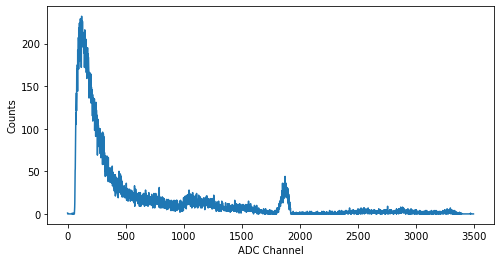

In [65]:
#spectrum background
range_bg = (bg["d"]["channels"] > 0) & (bg["d"]["channels"] < 3500)
plt.figure(figsize=(8, 4))
plt.plot(bg["d"]["channels"][range_bg], bg["d"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

#### 18/03

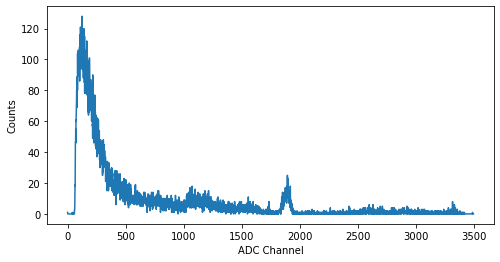

In [64]:
#spectrum background
range_bg = (bg["m"]["channels"] > 0) & (bg["m"]["channels"] < 3500)

plt.figure(figsize=(8, 4))
plt.plot(bg["m"]["channels"][range_bg], bg["m"]["counts"][range_bg])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

### Na22

#### 17/12

In [59]:
for key in na22d:
    counts_bg_na22 = bg["d"]["counts"] * (na22d[key]["time"] / bg["d"]["time"])
    na22d[key]["netcounts"] = na22d[key]["counts"] - counts_bg_na22
    na22d[key]["netcounts"][na22d[key]["netcounts"] < 0] = 0

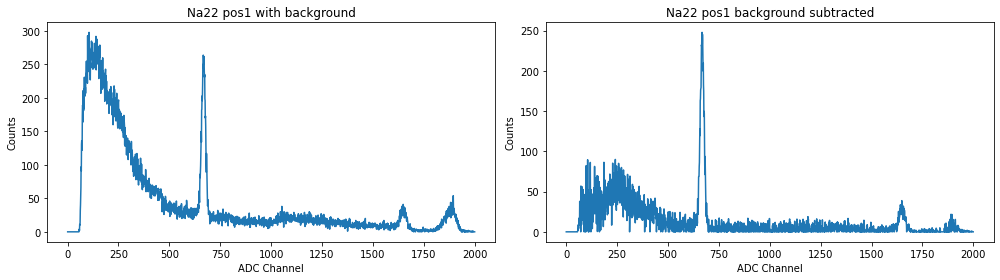

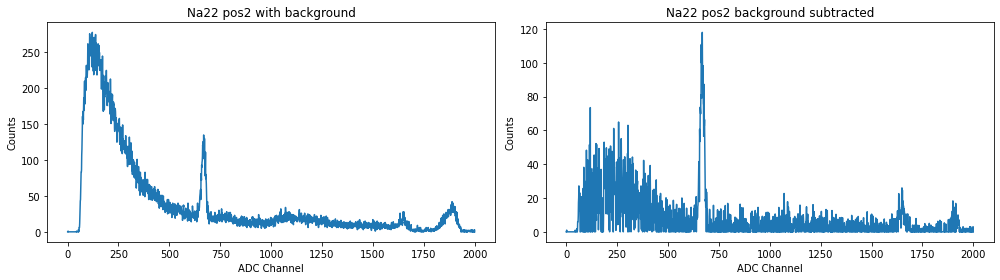

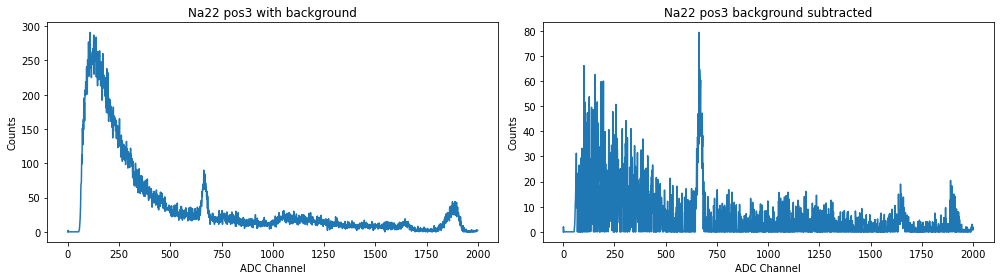

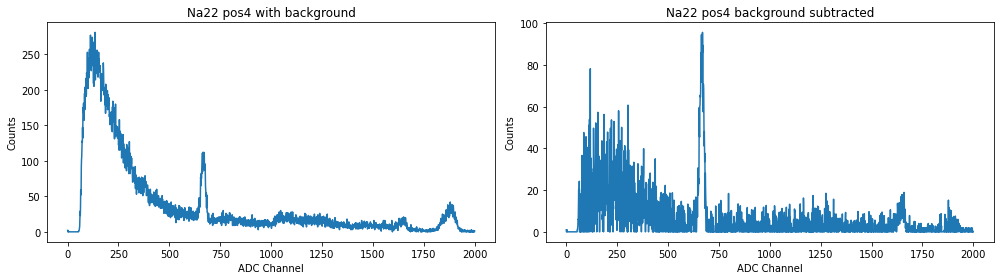

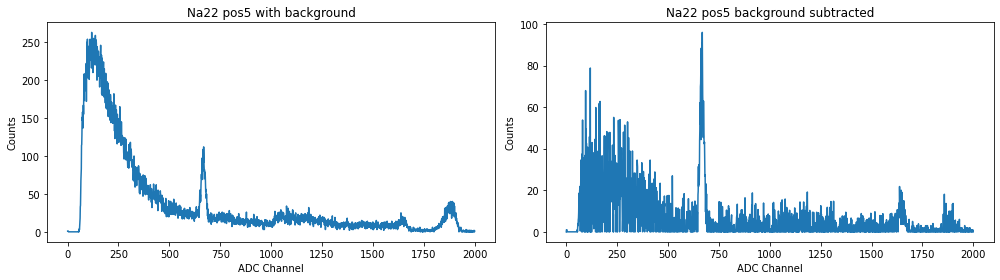

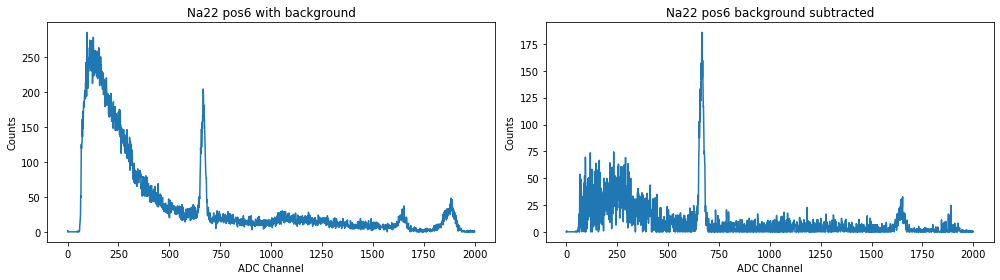

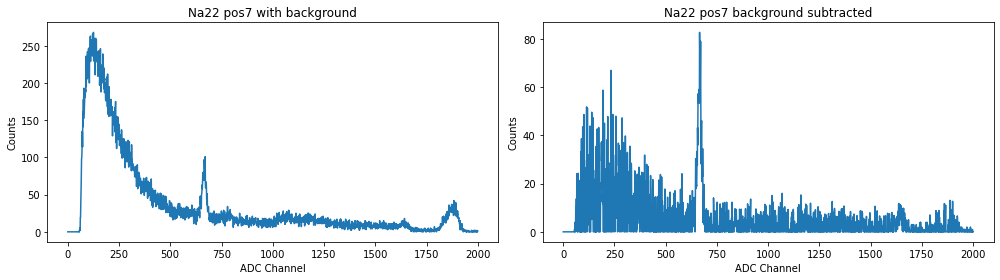

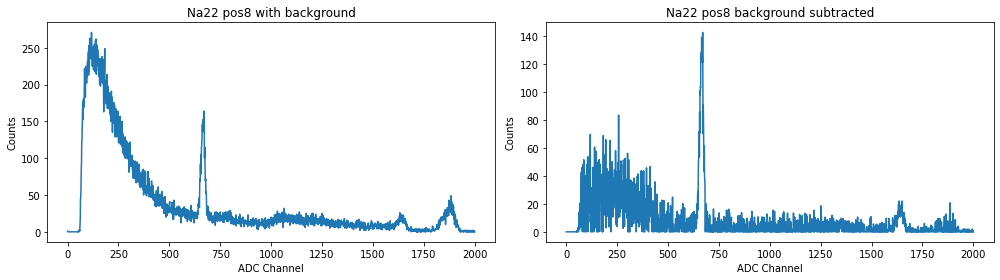

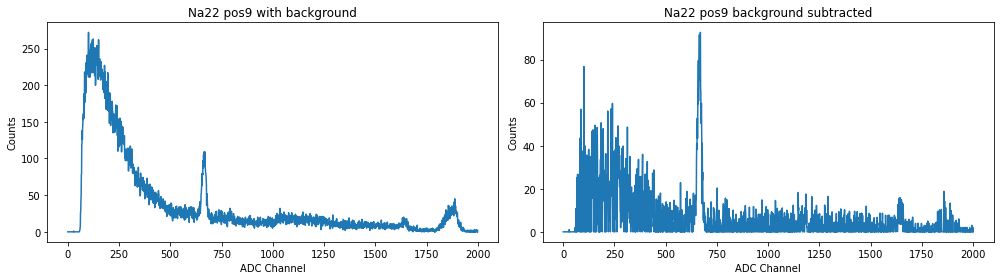

In [66]:
for key in na22d:
    range_na22 = (na22d[key]["channels"] > 0) & (na22d[key]["channels"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns
    
    ax[0].plot(na22d[key]["channels"][range_na22], na22d[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22d[key]["channels"][range_na22], na22d[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()

#### 18/03

In [67]:
for key in na22m:
    counts_bg_na22 = bg["m"]["counts"] * (na22m[key]["time"] / bg["m"]["time"])
    na22m[key]["netcounts"] = na22m[key]["counts"] - counts_bg_na22
    na22m[key]["netcounts"][na22m[key]["netcounts"] < 0] = 0

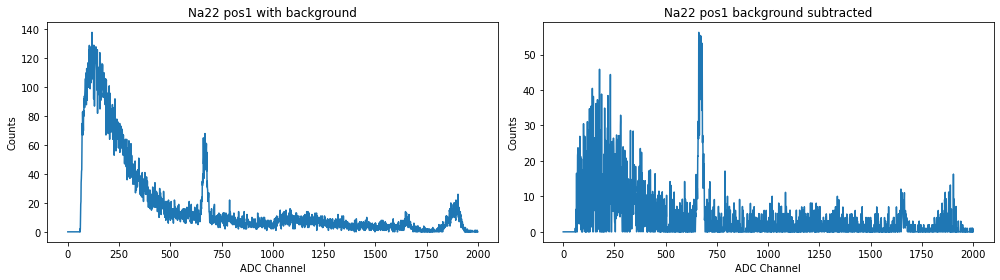

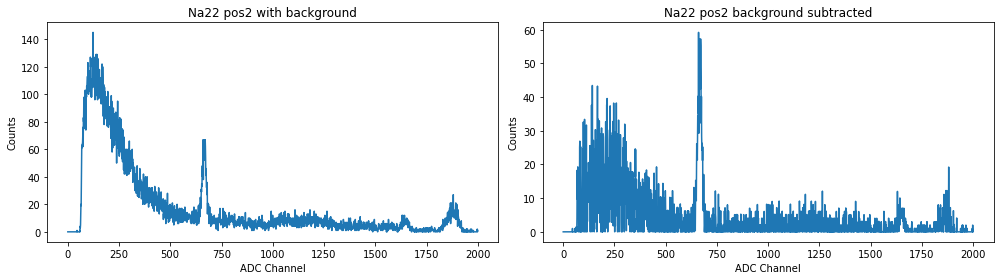

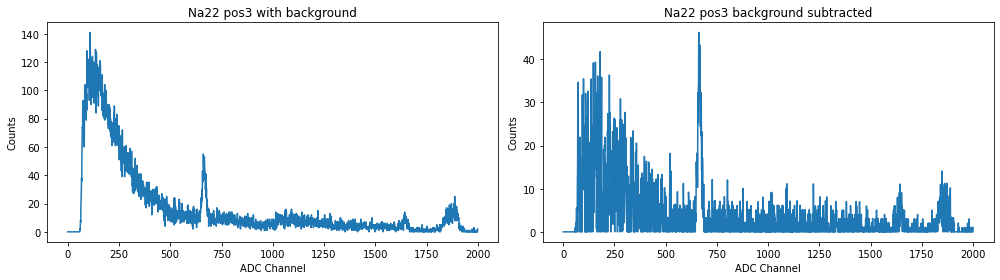

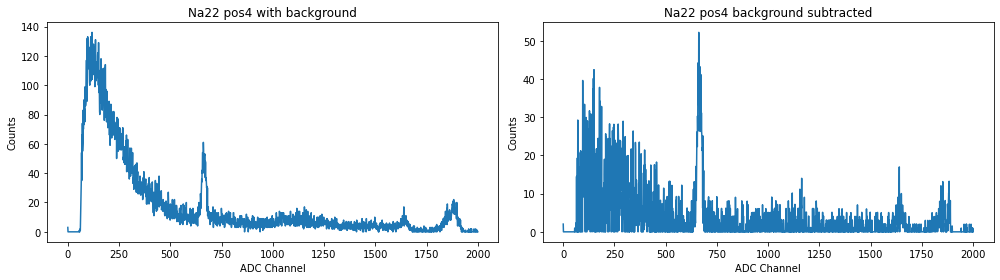

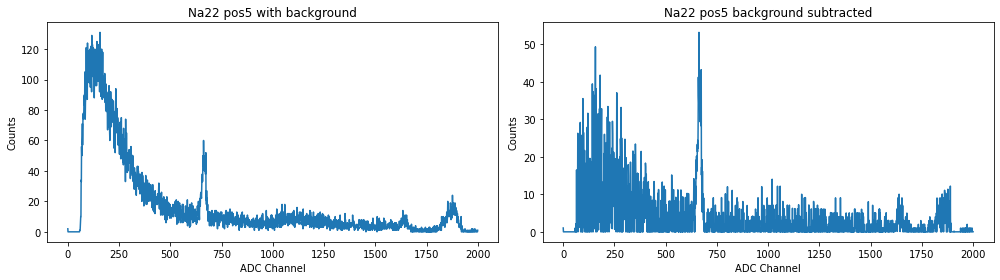

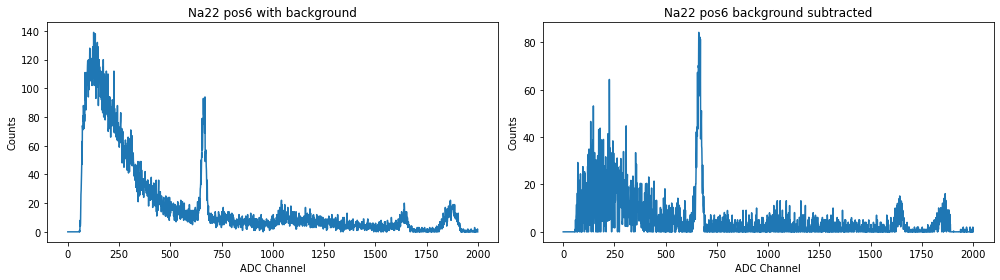

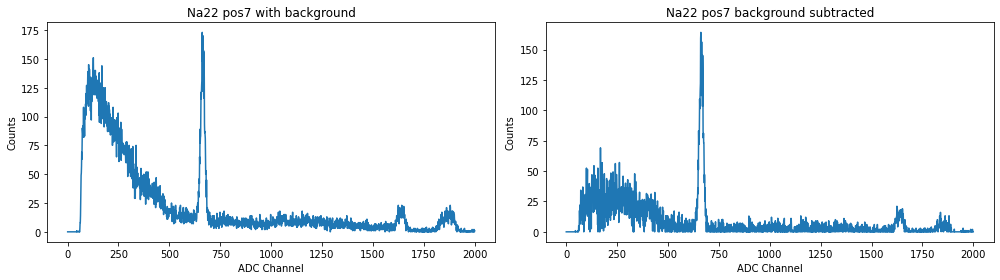

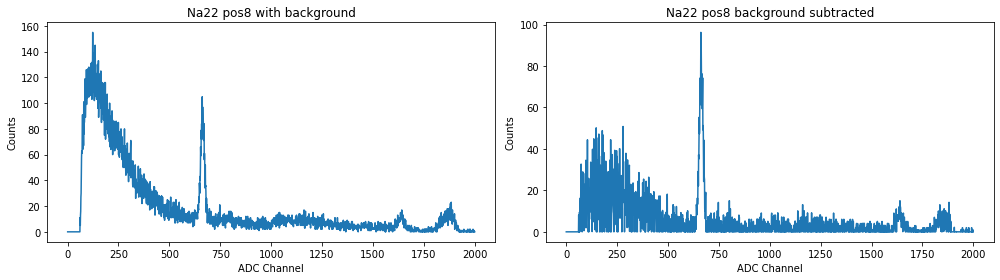

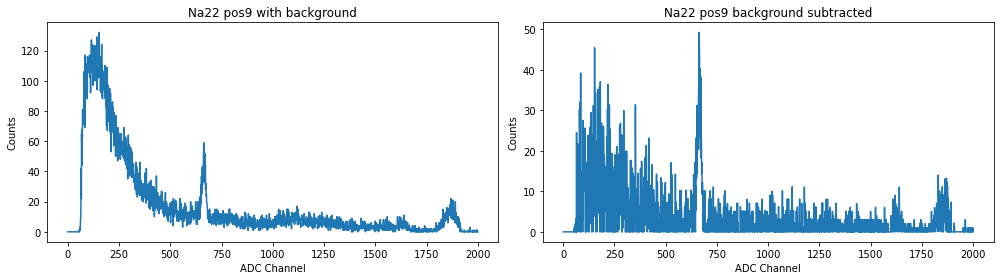

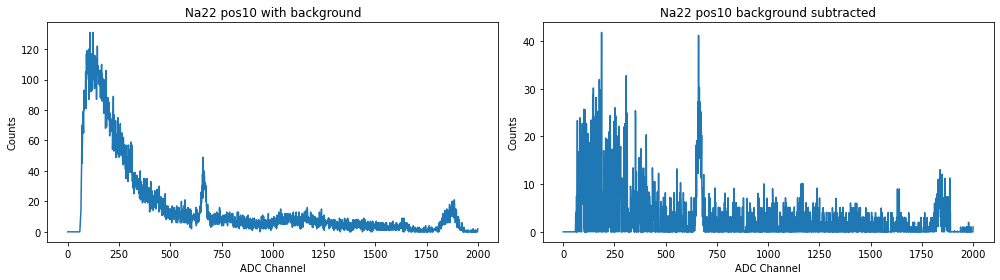

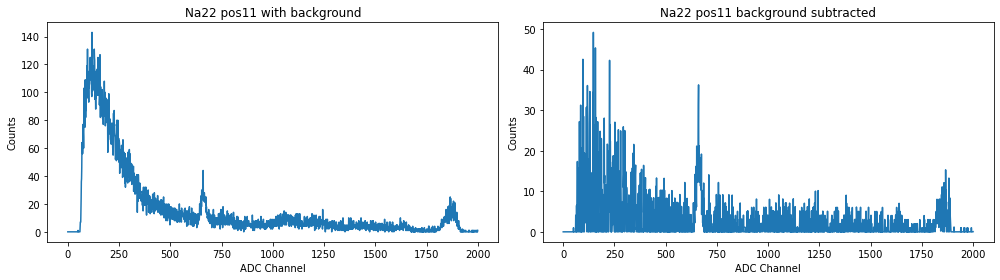

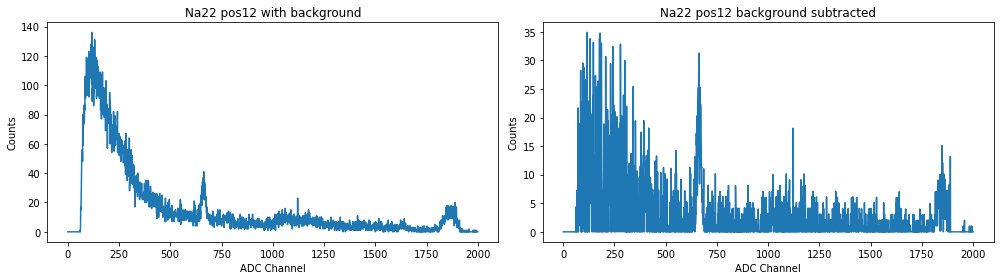

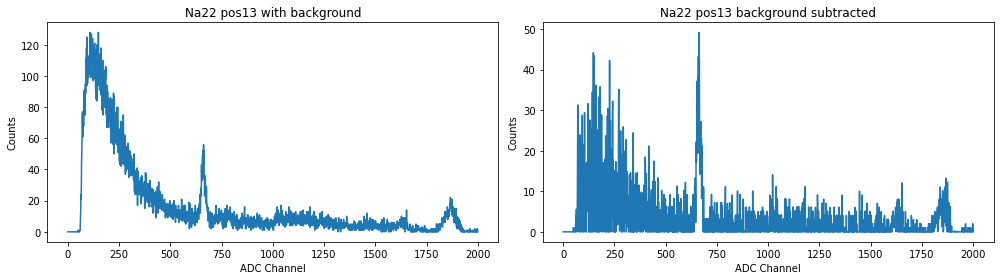

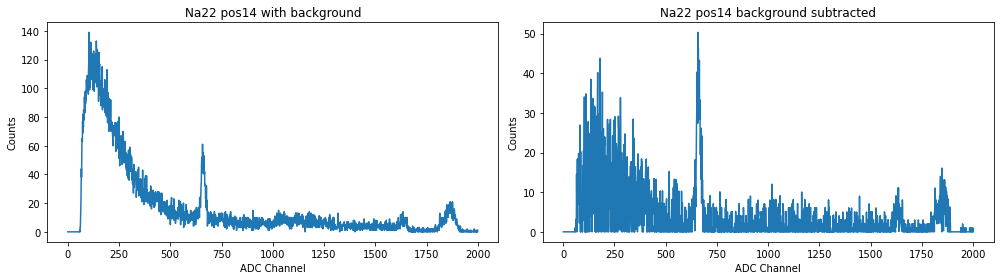

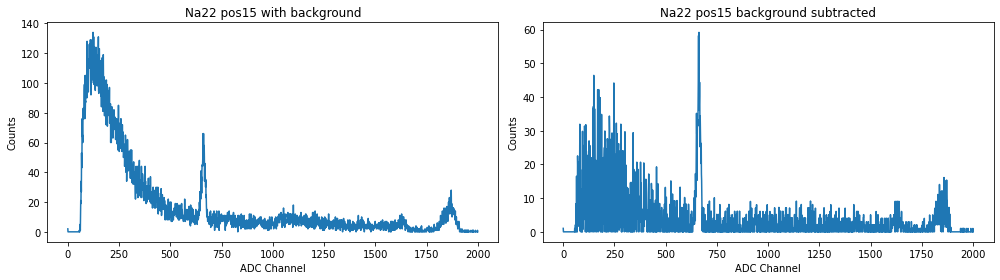

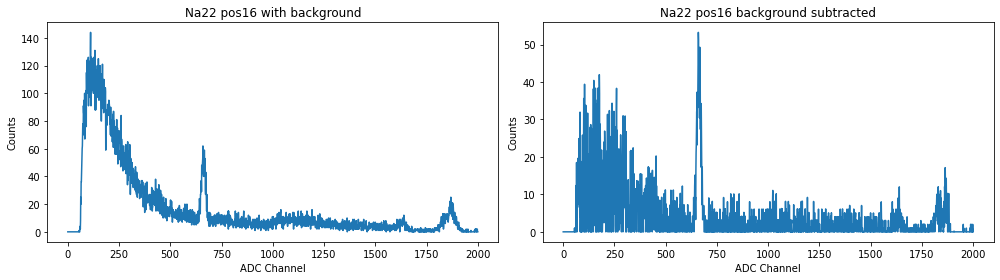

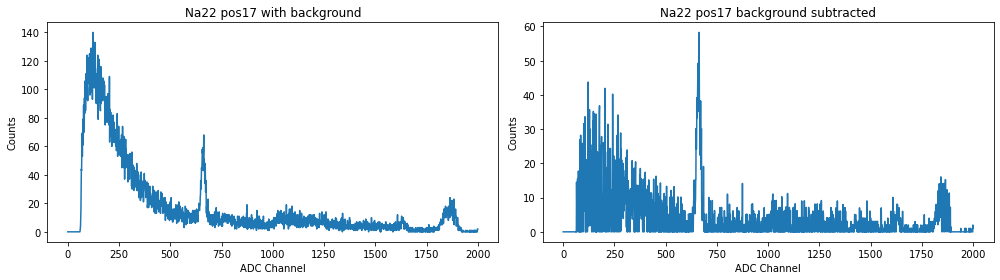

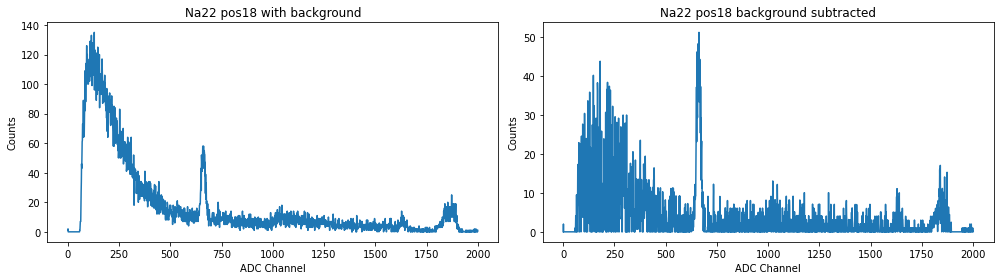

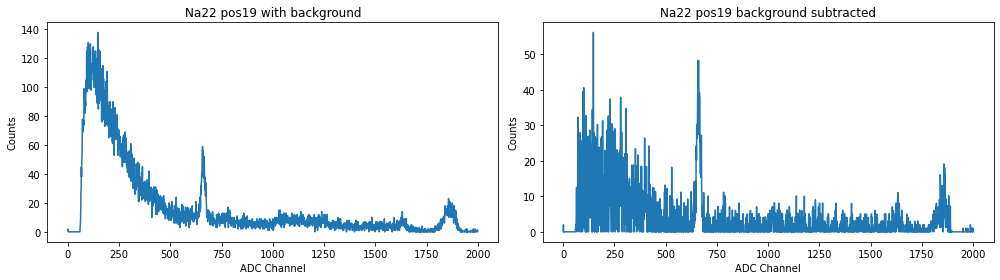

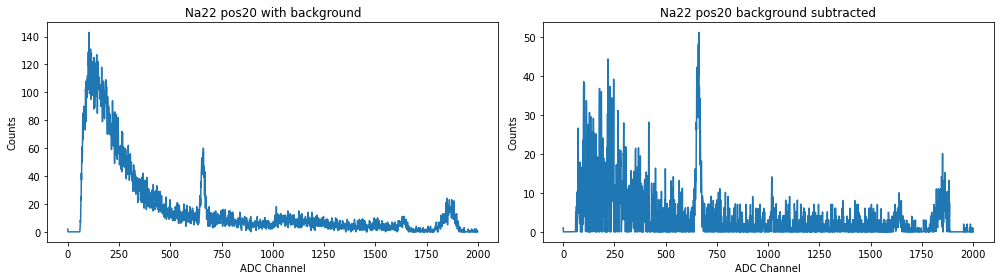

In [68]:
for key in na22m:
    range_na22 = (na22m[key]["channels"] > 0) & (na22m[key]["channels"] < 2000)
    
    fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns
    
    ax[0].plot(na22m[key]["channels"][range_na22], na22m[key]["counts"][range_na22])
    ax[0].set_title(f"Na22 pos{key} with background")
    ax[0].set_xlabel("ADC Channel")
    ax[0].set_ylabel("Counts")

    ax[1].plot(na22m[key]["channels"][range_na22], na22m[key]["netcounts"][range_na22])
    ax[1].set_title(f"Na22 pos{key} background subtracted")
    ax[1].set_xlabel("ADC Channel")
    ax[1].set_ylabel("Counts")

    plt.tight_layout()
    plt.show()